# Лабораторная работа: Интерполяция рациональными функциями Беррута




## Необходимо реалиозовать метод Беррута

In [14]:
import numpy as np

class BerrutInterpolator:
    def __init__(self, x, y):
        self.x = np.array(x, dtype=float)
        self.y = np.array(y, dtype=float)
        self.n = len(x)
        self.w = self._compute_weights()  

    def _compute_weights(self):
        n = self.n
        x = self.x
        w = np.ones(n)

        for k in range(n):
            for j in range(n):
                if j != k:
                    w[k] /= (x[k] - x[j])
        return w

    def __call__(self, x_new):
        x_new = np.array(x_new, dtype=float)
        result = np.zeros_like(x_new)

        for idx, x in enumerate(x_new):

            mask = np.isclose(x, self.x)
            if mask.any():
                result[idx] = self.y[mask][0]
                continue

            numerator = 0.0
            denominator = 0.0

            for k in range(self.n):
                temp = self.w[k] / (x - self.x[k])
                numerator += temp * self.y[k]
                denominator += temp

            result[idx] = numerator / denominator

        return result


In [15]:
import numpy as np

class BerrutInterpolator:
    def __init__(self, x, y):
        self.x = np.array(x, dtype=float)
        self.y = np.array(y, dtype=float)
        self.n = len(x)

    def __call__(self, x_new):
        x_new = np.array(x_new, dtype=float)
        result = np.zeros_like(x_new)

        for i, x0 in enumerate(x_new):
            if np.any(np.isclose(x0, self.x)):
                result[i] = self.y[np.isclose(x0, self.x)][0]
                continue

            # чередующиеся веса (-1)^k
            w = (-1) ** np.arange(self.n)
            num = np.sum((w * self.y) / (x0 - self.x))
            den = np.sum(w / (x0 - self.x))
            result[i] = num / den
        return result


## 1: Феномен Рунге
Провести сравнительный анализ интерполяции функции Рунге методами Беррута и полинома Лагранжа. Построить графики интерполяционных приближений и исходной функции, сравнить поведение методов, а также сделать выводы о качестве аппроксимации.

Необходимо:

1. Построить интерполяционные полиномы Лагранжа и Беррута для функции Рунге на выбранных узлах.

2. Визуализировать оригинальную функцию и интерполяционные результаты обоих методов.


3. Сделать выводы о преимуществах и недостатках каждого метода на данной задаче.

In [16]:
def runge_func(x):
    return 1.0 / (1.0 + 25*x**2)

x_min, x_max = -5, 5


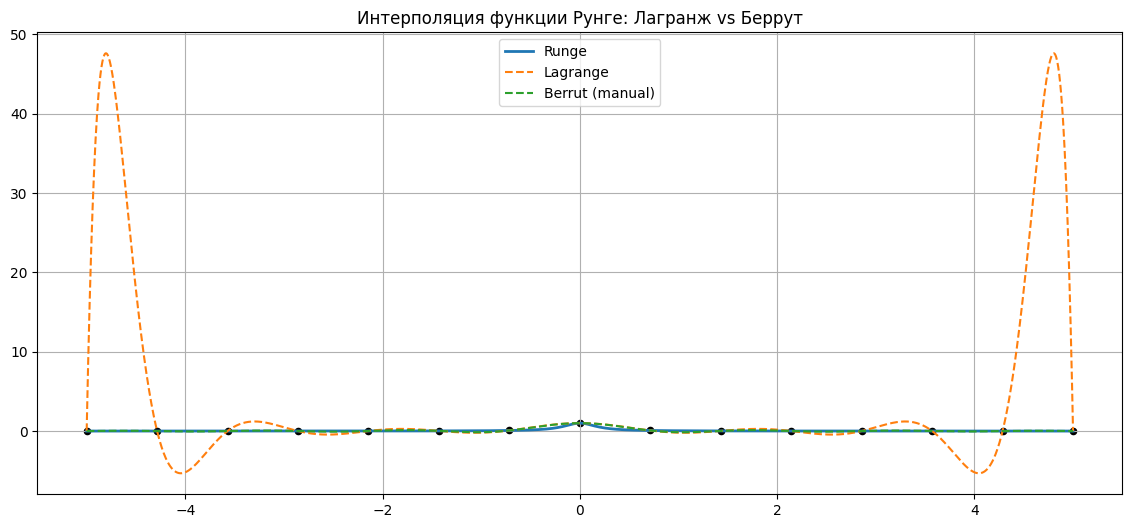

In [17]:
import matplotlib.pyplot as plt
from scipy.interpolate import KroghInterpolator

# Функция Рунге
def runge_func(x):
    return 1/(1+25*x*x)

# Узлы
x_nodes = np.linspace(-5, 5, 15)
y_nodes = runge_func(x_nodes)

# Интерполяторы
lagrange_interp = KroghInterpolator(x_nodes, y_nodes)
berrut_interp = BerrutInterpolator(x_nodes, y_nodes)

# Графики
x_dense = np.linspace(-5, 5, 2000)
y_true = runge_func(x_dense)
y_lagr = lagrange_interp(x_dense)
y_berr = berrut_interp(x_dense)

plt.figure(figsize=(14,6))
plt.plot(x_dense, y_true, label="Runge", linewidth=2)
plt.plot(x_dense, y_lagr, "--", label="Lagrange")
plt.plot(x_dense, y_berr, "--", label="Berrut (manual)")
plt.scatter(x_nodes, y_nodes, color="black", s=20)
plt.title("Интерполяция функции Рунге: Лагранж vs Беррут")
plt.grid()
plt.legend()
plt.show()


## 2: Анализ ошибок
Для полученных интерполяционных результатов (Беррута и Лагранжа) на функции Рунге вычислить следующие показатели точности:

1. Средняя абсолютная ошибка (Mean Absolute Error, MAE)

2. Максимальная абсолютная ошибка

3. Среднеквадратичная ошибка (Root Mean Squared Error, RMSE)

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def max_error(y, y_pred):
    return np.max(np.abs(y - y_pred))

errors = {
    "MAE_Lagrange": mean_absolute_error(y_true, y_lagr),
    "MAE_Berrut": mean_absolute_error(y_true, y_berr),
    "MAX_Lagrange": max_error(y_true, y_lagr),
    "MAX_Berrut": max_error(y_true, y_berr),
    "RMSE_Lagrange": np.sqrt(mean_squared_error(y_true, y_lagr)),
    "RMSE_Berrut": np.sqrt(mean_squared_error(y_true, y_berr)),
}

errors


{'MAE_Lagrange': 4.469141052203946,
 'MAE_Berrut': 0.0848630009812508,
 'MAX_Lagrange': np.float64(47.605577139757784),
 'MAX_Berrut': np.float64(0.4466364288148911),
 'RMSE_Lagrange': np.float64(11.733278298314566),
 'RMSE_Berrut': np.float64(0.13015506719127296)}

## 3: Тестирование интерполяционных методов на различных функциях
Провести сравнительный анализ методов интерполяции Лагранжа и Беррута на нескольких тестовых функциях. Для каждого метода построить интерполяционные полиномы, визуализировать результаты и оценить качество аппроксимации.
Рекомендуемые функции для тестирования:
### Список функций для тестирования

- **Функция 1:**  
  $$ f_1(x) = \sin(x), \quad x \in [-\pi, \pi] $$

- **Функция 2:**  
  $$ f_2(x) = e^x, \quad x \in [-2, 2] $$

- **Функция 3:**  
  $$ f_3(x) = x^2 \sin(x), \quad x \in [-5, 5] $$

- **Функция 4:**  
  $$ f_4(x) = |x|, \quad x \in [-3, 3] $$

- **Функция 5:**  
  $$ f_5(x) = \sin(10x) e^{-x^2}, \quad x \in [-3, 3] $$


Необходимо выполнить
1. Провести интерполяцию для каждой функции на равномерной и неравномерной сетке узлов.

2. Построить графики исходных функций и интерполяционных полиномов для обоих методов.

3. Сравнить визуально и численно (по погрешности) результаты для методов Лагранжа и Беррута.



In [19]:
functions = [
    (lambda x: np.sin(x), -np.pi, np.pi, "sin(x)"),
    (lambda x: np.exp(x), -2, 2, "exp(x)"),
    (lambda x: x**2*np.sin(x), -5, 5, "x^2 sin(x)"),
    (lambda x: np.abs(x), -3, 3, "|x|"),
    (lambda x: np.sin(10*x)*np.exp(-x**2), -3, 3, "sin(10x)*exp(-x^2)")
]


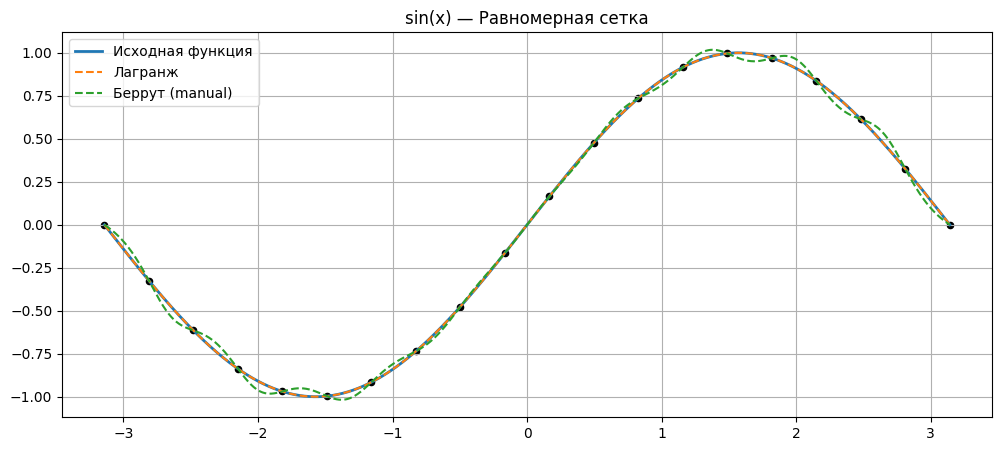

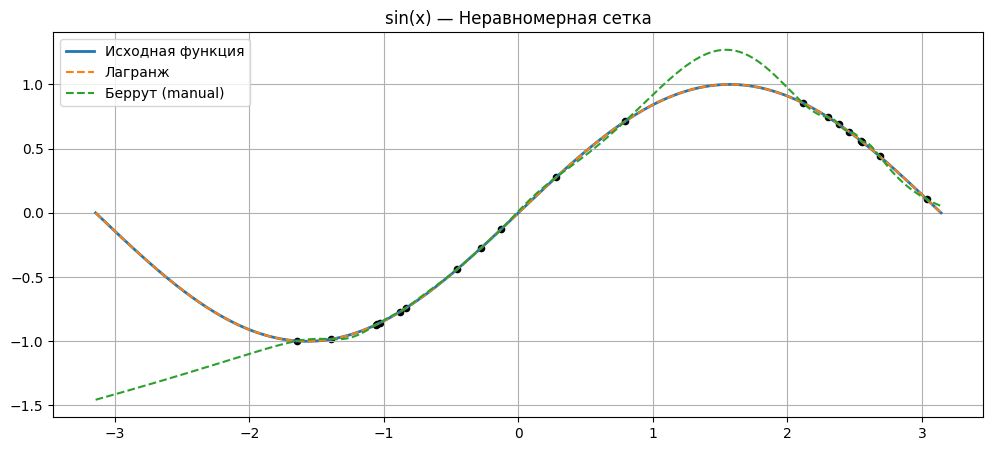

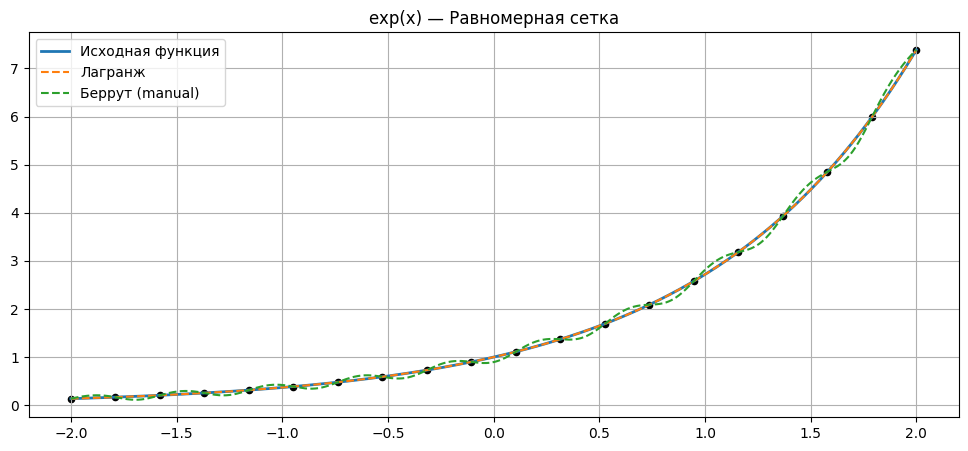

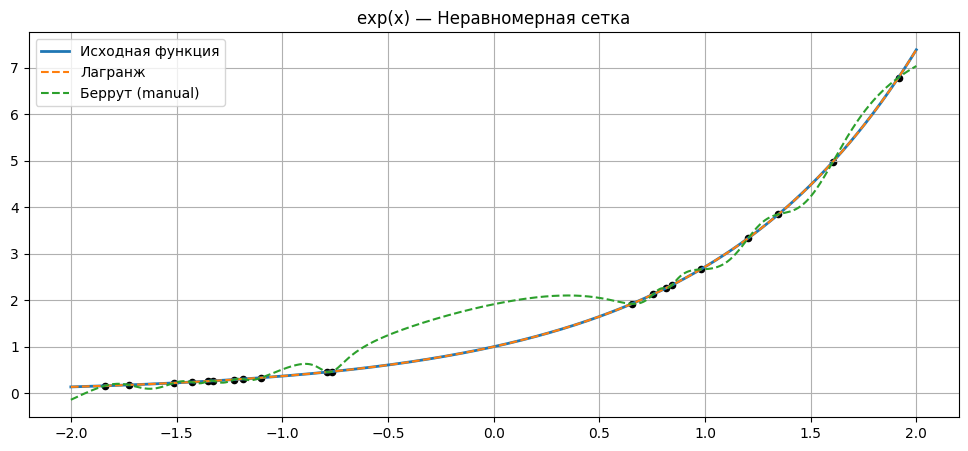

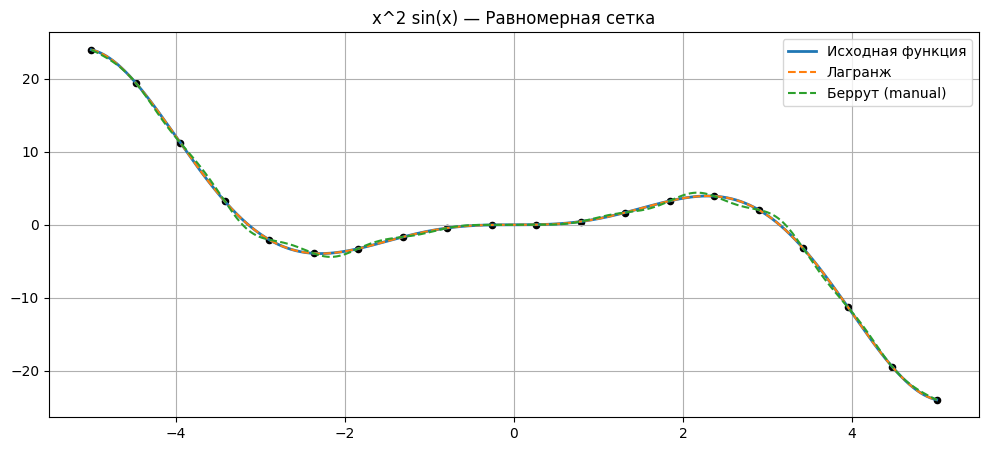

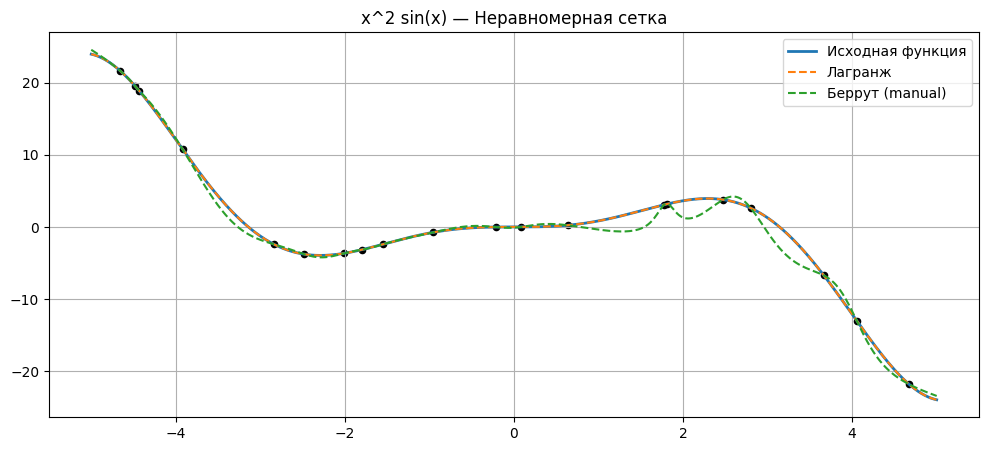

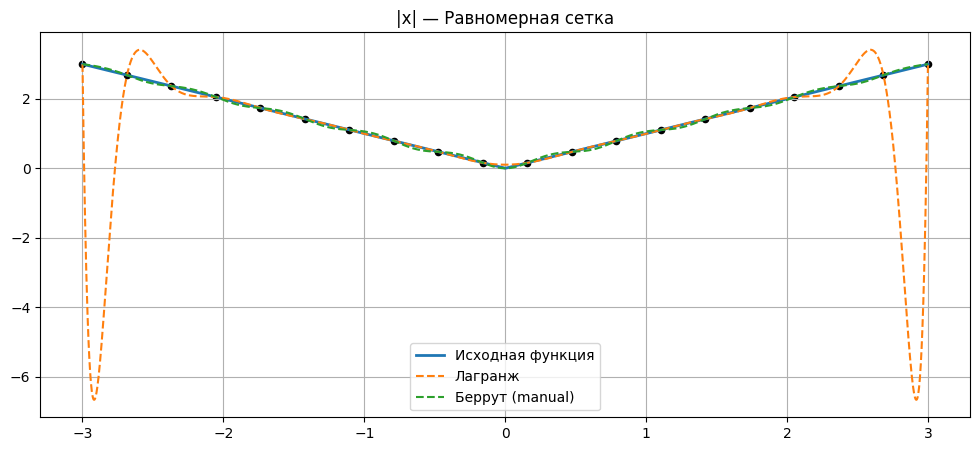

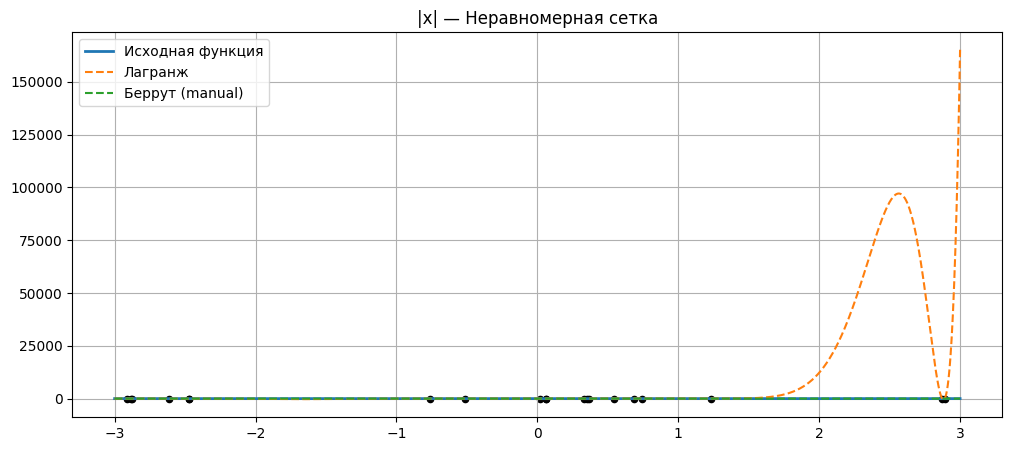

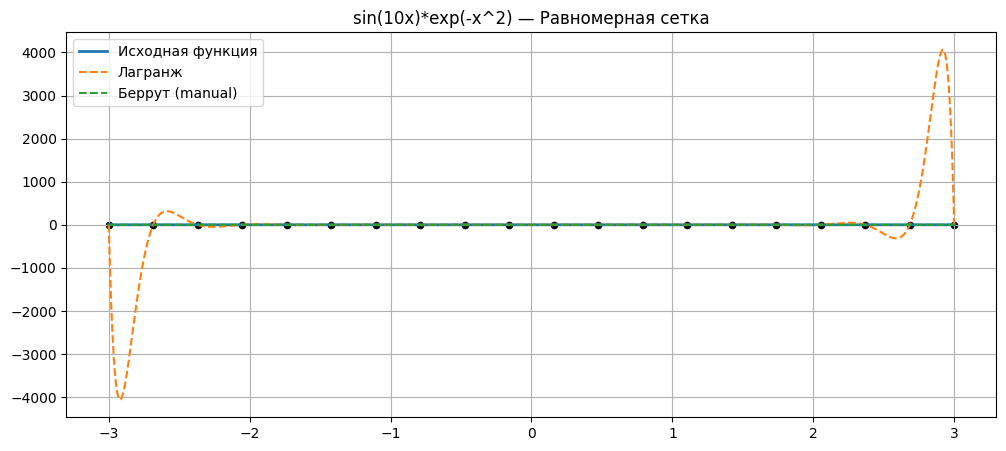

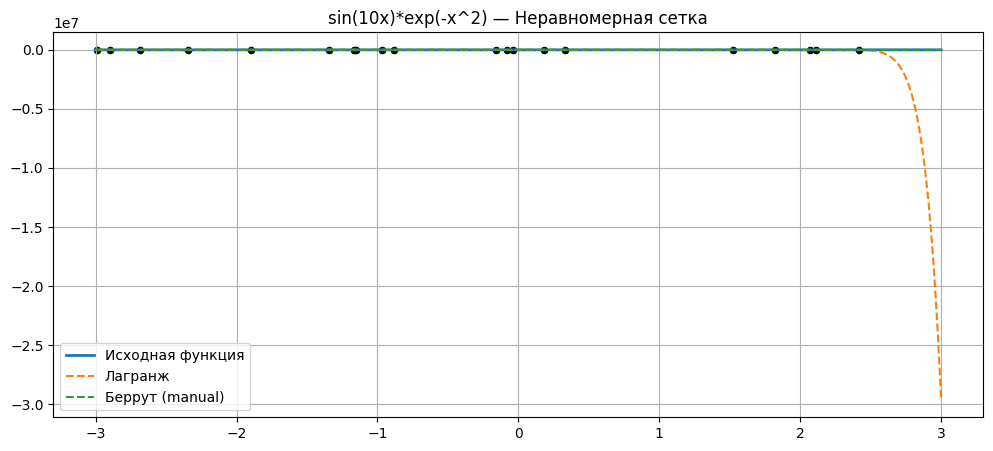

In [20]:
def test_function(f, xmin, xmax, name):
    nodes_uniform = np.linspace(xmin, xmax, 20)
    nodes_nonuniform = np.sort(np.random.uniform(xmin, xmax, 20))

    def plot(nodes, description):
        y = f(nodes)
        
        lag = KroghInterpolator(nodes, y)
        berr = BerrutInterpolator(nodes, y)

        x_dense = np.linspace(xmin, xmax, 2000)

        plt.figure(figsize=(12,5))
        plt.plot(x_dense, f(x_dense), label="Исходная функция", linewidth=2)
        plt.plot(x_dense, lag(x_dense), "--", label="Лагранж")
        plt.plot(x_dense, berr(x_dense), "--", label="Беррут (manual)")
        plt.scatter(nodes, y, color="black", s=20)
        plt.title(f"{name} — {description}")
        plt.grid()
        plt.legend()
        plt.show()

    plot(nodes_uniform, "Равномерная сетка")
    plot(nodes_nonuniform, "Неравномерная сетка")

for f, a, b, name in functions:
    test_function(f, a, b, name)


## 4: Интерполяция зашумленных данных
Провести сравнительный анализ методов интерполяции Лагранжа и Беррута на зашумленных данных. Необходимо построить графики, включающие:

1. График интерполяции, на котором изображены оригинальная функция, зашумленные точки и результаты интерполяции двумя методами.

2. График сравнения ошибок интерполяции каждого метода.

Варианты:
* Вариант 1: равномерные узлы, низкий гауссов шум

* Вариант 2: равномерные узлы, высокий гауссов шум



Ваш вариант: номер по списку % 2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import BarycentricInterpolator, KroghInterpolator

# Исходная функция
def f(x):
    return np.sin(2*x)

# Генерация данных с шумом
def generate_data(nodes, noise_level, noise_type='gaussian'):
    y_true = f(nodes)
    if noise_type == 'gaussian':
        noise = np.random.normal(0, noise_level, size=nodes.shape)
    y_noisy = y_true + noise
    return y_true, y_noisy

# Варианты узлов
uniform_nodes = np.linspace(-3, 3, 12)
nonuniform_nodes = np.sort(np.random.uniform(-3, 3, 12))

# Список вариантов с параметрами: (узлы, уровень шума, тип шума, описание)
#Необходимо выбрать свой
variants = [
    (uniform_nodes, 0.05, 'gaussian', 'Равномерные узлы, низкий шум'),
    (uniform_nodes, 0.2, 'gaussian', 'Равномерные узлы, высокий шум')
]




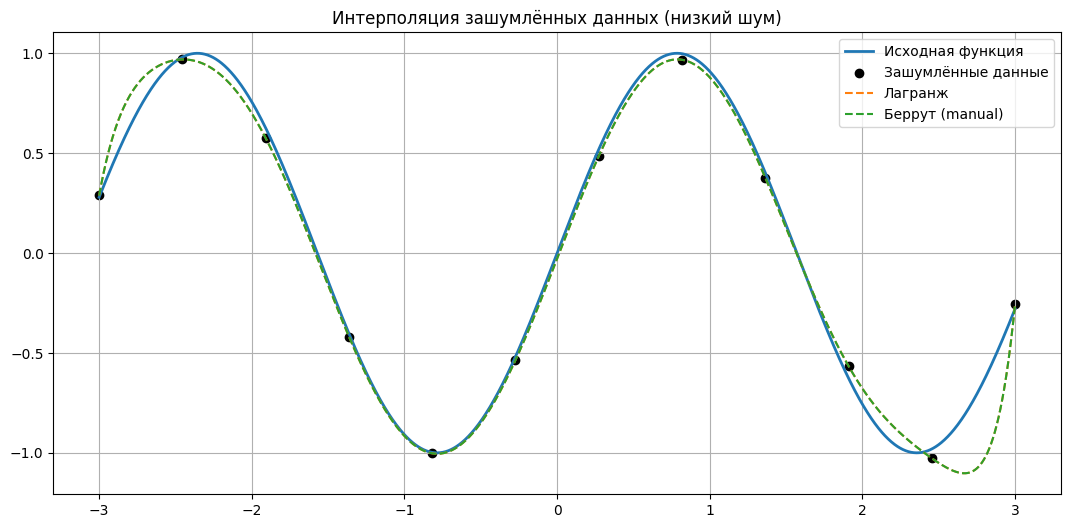

In [ ]:
def f(x):
    return np.sin(2*x)

def generate_data(nodes, noise):
    return f(nodes), f(nodes) + np.random.normal(0, noise, size=len(nodes))

nodes = np.linspace(-3, 3, 12)
y_true, y_noisy = generate_data(nodes, 0.05)

lag = KroghInterpolator(nodes, y_noisy)
berr = BerrutInterpolator(nodes, y_noisy)

x_dense = np.linspace(-3, 3, 2000)

plt.figure(figsize=(13,6))
plt.plot(x_dense, f(x_dense), label="Исходная функция", linewidth=2)
plt.scatter(nodes, y_noisy, label="Зашумлённые данные", color="black")
plt.plot(x_dense, lag(x_dense), "--", label="Лагранж")
plt.plot(x_dense, berr(x_dense), "--", label="Беррут (manual)")
plt.grid()
plt.legend()
plt.title("Интерполяция зашумлённых данных (низкий шум)")
plt.show()
